<a href="https://colab.research.google.com/github/winpeperk/dls/blob/main/week_08_semantic_segmentation/Homework/hw_6_semantic_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Шаг 1. Загрузка и подготовка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>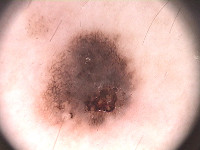</td><td>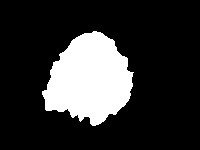</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [1]:
!gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

Downloading...
From (original): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
From (redirected): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql&confirm=t&uuid=19ec6ae3-3192-4c8e-9746-399bf319a815
To: /content/PH2Dataset.rar
100% 162M/162M [00:02<00:00, 75.1MB/s]


In [2]:
get_ipython().system_raw("unrar x PH2Dataset.rar")

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [3]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [4]:
from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [5]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

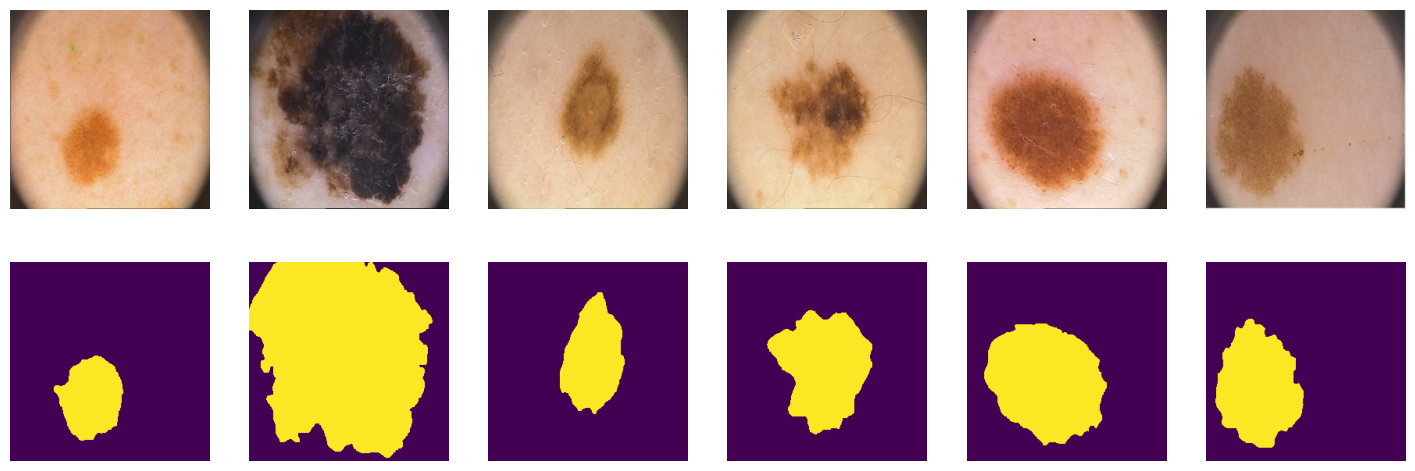

In [6]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на 100/50/50
 для обучения, валидации и теста соответственно

In [7]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [8]:
print(len(tr), len(val), len(ts))

100 50 50


## PyTorch DataLoader

In [9]:
from torch.utils.data import DataLoader
batch_size = 25
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=False)

In [10]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Шаг 2. Метрика качества модели

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:





<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN" width=1000 height=800/></p>

In [11]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.5 MB/s eta 0:00:00


In [12]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

# Задания: Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## Шаг 3. Loss функция - BCE [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

**Ответ:**  
Распишем сигмоиду  $σ = \frac{1}{1 + \exp(-\hat y)}$  
Подставим в исходную формулу BCE:  

$$
-\sum_i \left[y_i\log\frac{1}{1 + \exp(-\hat y_i)} + (1-y_i)\log(1-\frac{1}{1 + \exp(-\hat y_i)})\right]
$$

Сделаем несколько преобразований  

$$
-\sum_i \left[y_i\log\frac{1}{1 + \exp(-\hat y_i)} + (1-y_i)\log(\frac{\exp(-\hat y_i)}{1 + \exp(-\hat y_i)})\right]
$$  

Используем $\log(\frac{a}{b}) = \log(a) - \log(b)$

$$
-\sum_i \left[- y_i \cdot \log(1 + \exp(-\hat y_i)) + (1-y_i) \cdot ( \log(\exp(- \hat y_i)) - \log(1 + \exp(-\hat y_i)) \right]
$$

$$
-\sum_i \left[- (y_i + 1 - y_i) \cdot \log(1 + \exp(-\hat y_i)) + (1-y_i) \cdot \log(\exp(- \hat y_i)) \right]
$$

Используем $\log(a^b) = b\log(a)$

$$
\sum_i \left[ \log(1 + \exp(-\hat y_i)) + (1-y_i) \hat y_i \right ]
$$

Получившая формула

$$
\mathcal L_{BCE} = \sum_i \left[ \hat y_i - \hat y_i y + \log(1 + \exp(-\hat y_i)) \right ]
$$

### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [13]:
import torch.nn.functional as F
import torch.nn as nn
import torch
import numpy as np
import matplotlib.pyplot as plt

In [14]:
bce_torch = nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [15]:
def bce_loss(y_pred, y_real):
  return torch.sum(y_pred - y_pred * y_real + torch.log(1 + torch.exp(-y_pred)))

def bce_true(y_pred, y_real):
  y_pred = torch.sigmoid(y_pred)
  return - torch.sum(y_real * torch.log(y_pred) + (1 - y_real) * torch.log(1 - y_pred))

Проверим корректность работы на простом примере

In [16]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss             = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный                = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch              = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch  = {bce_torch_with_logits(y_pred, y_true)}')

BCE loss from scratch bce_loss             = 4.856348991394043
BCE loss честно посчитанный                = 4.856348991394043
BCE loss from torch bce_torch              = 4.856348991394043
BCE loss from torch with logits bce_torch  = 4.856349468231201


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [17]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [18]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный               = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch             = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss            = 10.133766174316406
BCE loss честно посчитанный               = 10.133766174316406
BCE loss from torch bce_torch             = 10.13376522064209
BCE loss from torch with logits bce_torch = 10.133766174316406


In [19]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [20]:
!gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

Retrieving folder contents
Processing file 1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC labels.pt
Processing file 1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I logits.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
To: /content/for_asserts/labels.pt
100% 1.18k/1.18k [00:00<00:00, 3.84MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I
To: /content/for_asserts/logits.pt
100% 1.18k/1.18k [00:00<00:00, 5.41MB/s]
Download completed


In [21]:
train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

device = torch.device("cuda")

CUDA is available!  Training on GPU ...


In [22]:
path_to_dummy_samples = '/content/for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels']
dummpy_sample['logits'] = dummpy_sample['logits']

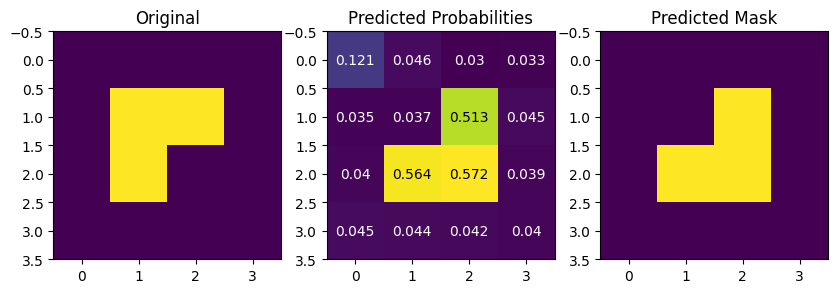

In [23]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [24]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

## Шаг 4. Модель SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

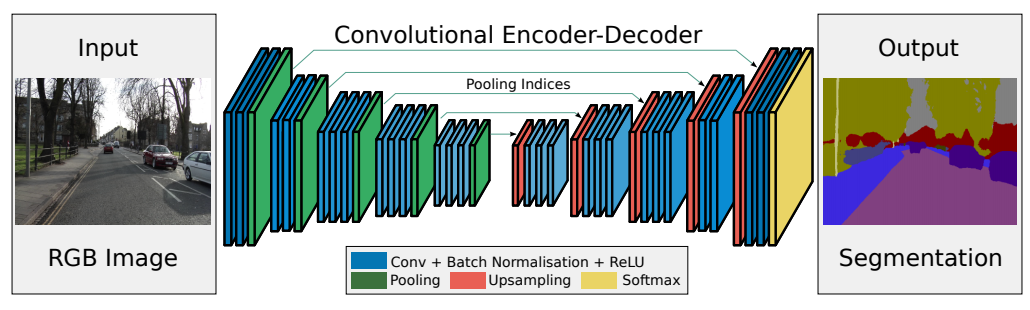

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки. Для этого скачаем и изучим feature extractor VGG-16, который лежит в основе SegNet.

In [ ]:
model_vgg16 = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 80.2MB/s]


In [ ]:
model_vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Feature extractor VGG-16 состоит из 5 блоков:
- два блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
- три блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d

В первом блоке - на входе три канала (по числу каналов в изображениях), которые конволюционный слой преобразует в 64 канала.

Во втором, третьем и четвертом блоках первый конволюционный слой удваивает количество каналов, а последующие конволюционные слои не меняют количество каналов.

В последнем блоке число каналов от слоя к слою не меняется.

Теперь напишем код одного блока энкодера нашей модели SegNet.  

In [26]:
# Параметрами блока будут:
# - количество каналов на входе
# - количество каналов на выходе
# - глубина блока (2 или 3, по количеству конволюционных слоев)
# - kernel_size и padding

class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__() # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList() # в self.layers будем добавлять слои блока
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #добавляем MaxPool с индексами для последующего Unpooling

    # Обратите внимание: на вход метод forward() получает карту признаков (х),
    # а возвращает карту признаков и индексы для последующего Unpooling
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices

По аналогии напишите код одного блока декодера.

К карте признаков на входе каждого блока примеяется nn.MaxUnpool2d с индексами из симметричного блока энкодера. Затем повторяется связка Conv + Batch Normalization + ReLU. Количество каналов меняется зеркально блокам энкодера:
- в первом блоке декодера количество каналов не меняется
- во 2-4 блоках декодера количество каналов уменьшается в 2 раза после прохождения последнего конволюционного слоя
- на выходе из последнего блока декодера 1 канал

Обратите внимание, что после последней конволюции последнего блока декодера не применяется батч-нормализация и функция активации.

In [27]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(DecoderBlock, self).__init__()

        self.maxunpooling = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.layers = nn.ModuleList()

        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

    def forward(self, x, indices):
        x = self.maxunpooling(x, indices)
        for layer in self.layers:
            x = layer(x)
        return x

Соединим блоки энкодера и декодера в модель SegNet:

In [28]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels = 1, num_features = 64) -> None:
        super(SegNet, self).__init__()

        # Encoder
        self.encoder0 = EncoderBlock(in_channels, num_features, depth=2) # 3 -> 64
        self.encoder1 = EncoderBlock(num_features, num_features * 2, depth=2) # 64 -> 128
        self.encoder2 = EncoderBlock(num_features * 2, num_features * 4, depth=3) # 128 -> 256
        self.encoder3 = EncoderBlock(num_features * 4, num_features * 8, depth=3) # 256 -> 512

        # Encoder bottleneck - количество каналов на входе и на выходе одинаково
        self.encoder4 = EncoderBlock(num_features * 8, num_features * 8, depth=3) # 512 -> 512

        # Decoder bottleneck
        self.decoder4 = DecoderBlock(num_features * 8, num_features * 8, depth=3) # 512 -> 512

        # Decoder
        self.decoder3 = DecoderBlock(num_features * 8, num_features * 4, depth=3) # 512 -> 256
        self.decoder2 = DecoderBlock(num_features * 4, num_features * 2, depth=3) # 256 -> 128
        self.decoder1 = DecoderBlock(num_features * 2, num_features, depth=2) # 128 -> 64
        self.decoder0 = DecoderBlock(num_features, out_channels, depth=2) # 64 -> 1

    def forward(self, x):
        # encoder
        x, indices0 = self.encoder0(x)
        x, indices1 =  self.encoder1(x)
        x, indices2 =  self.encoder2(x)
        x, indices3 =  self.encoder3(x)
        x, indices4 =  self.encoder4(x)
        # TODO
        output = self.decoder4(x, indices4)
        output = self.decoder3(output, indices3)
        output = self.decoder2(output, indices2)
        output = self.decoder1(output, indices1)
        output = self.decoder0(output, indices0)
        return output

## Шаг 5. Тренировка модели [1 балл]

Напишите функции для обучения модели.

In [29]:
from tqdm.notebook import tqdm

In [30]:
def train_one_epoch(model, optimizer, criterion, train_dataloader, device):
  model.train()

  avg_loss = 0
  for x_batch, y_batch in tqdm(train_dataloader):
      x_batch = x_batch.to(device)
      y_batch = y_batch.to(device)

      optimizer.zero_grad()
      outp = model(x_batch)
      loss = criterion(outp, y_batch)
      loss.backward()
      optimizer.step()

      avg_loss += loss.item()

  avg_loss /= len(train_dataloader)

  return avg_loss


def valid_one_epoch(model, criterion, valid_dataloader, device, threshold):
  iou_score = JaccardIndex(threshold=threshold, task="binary").to(device)
  model.eval()

  avg_loss = 0

  for x_batch, y_batch in tqdm(valid_dataloader):
      x_batch = x_batch.to(device)
      y_batch = y_batch.to(device)

      with torch.no_grad():
          outp = model(x_batch)
          avg_loss += criterion(outp, y_batch).item()
          iou_score.update(outp, y_batch.int())

  avg_loss /= len(valid_dataloader)
  avg_iou = iou_score.compute().item()

  return avg_loss, avg_iou

In [31]:
def train(model, criterion, optimizer, train_dataloader, valid_dataloader, max_epochs=50, threshold=0.5, plot=True):
  total_train_loss = []
  total_val_loss = []
  total_val_iou = []
  model.to(device)

  for epoch in tqdm(range(max_epochs)):
    print(f'Epoch {epoch}')

    train_loss = train_one_epoch(model, optimizer, criterion, train_dataloader, device)
    print(f'Epoch {epoch}: train loss = {train_loss}')

    val_loss, val_iou = valid_one_epoch(model, criterion, valid_dataloader, device, threshold)
    print(f'Epoch {epoch}: val loss = {val_loss}')
    print(f'Epoch {epoch}: val iou = {val_iou}')

    total_train_loss.append(train_loss)
    total_val_loss.append(val_loss)
    total_val_iou.append(val_iou)

  if plot:
    fig, ax = plt.subplots(1, 2)
    print(f'Epoch with max val iou = {np.argmax(total_val_iou)}')
    ax[0].plot(list(range(len(total_train_loss))), total_train_loss, label = 'train loss')
    ax[0].plot(list(range(len(total_val_loss))), total_val_loss, label = 'val loss')
    ax[0].set_title("Loss")
    ax[0].legend()

    ax[1].plot(list(range(len(total_val_iou))), total_val_iou, label = 'val iou')
    ax[1].set_title("IoU")
    ax[1].legend()

    plt.show()

Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

Для воспроизводимости результатов

In [32]:
torch.backends.cudnn.deterministic = True

import random

def set_seed(seed=42):
    torch.manual_seed(seed)

    # CUDA (GPU)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # For multi-GPU setups

    # NumPy
    np.random.seed(seed)

    # Python's built-in random
    random.seed(seed)

set_seed()

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 0


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 0: train loss = 0.727013885974884


  0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 48: val loss = 0.6424041092395782
Epoch 48: val iou = 0.40652164816856384
Epoch 49


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 49: train loss = 0.58259217441082


  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 49: val loss = 0.6046754419803619
Epoch 49: val iou = 0.6482287049293518
Epoch with max val iou = 49


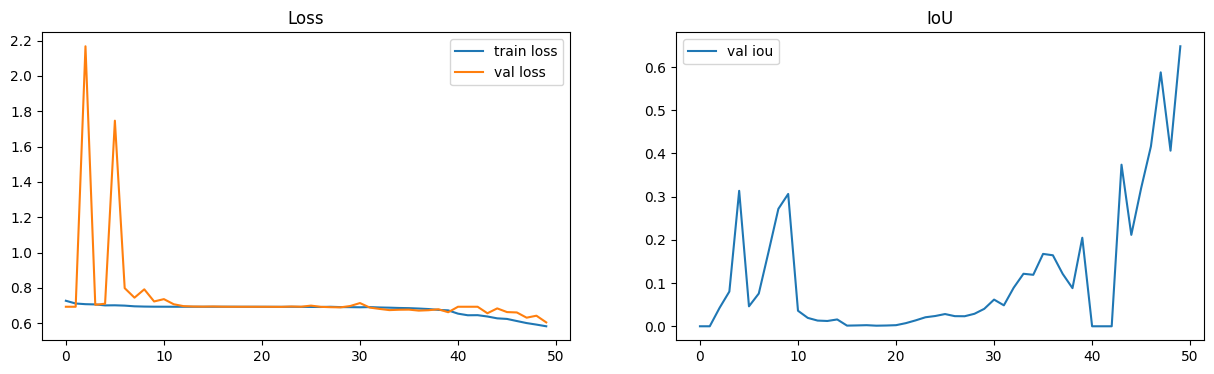

In [33]:
set_seed()
model = SegNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()
train(model, criterion, optimizer, train_dataloader, valid_dataloader)

Лучший достигнутый IoU = 0.6482287049293518.

## Шаг 6. Инференс [1 балл]

После обучения модели напишите функцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

Лучший score модель имела на 50 эпоху, поэтому сразу протестируем её.

In [34]:
def test(model, test_dataloader, device, threshold=0.5):
  iou_score = JaccardIndex(threshold=threshold, task="binary").to(device)
  model.eval()

  avg_iou = 0
  for x_batch, y_batch in tqdm(test_dataloader):
      x_batch = x_batch.to(device)
      y_batch = y_batch.to(device)

      with torch.no_grad():
          outp = model(x_batch)
          iou_score.update(outp, y_batch.int())

  avg_iou = iou_score.compute().item()

  print(f'Average test iou = {avg_iou}')

In [35]:
test(model, test_dataloader, device)

  0%|          | 0/2 [00:00<?, ?it/s]

Average test iou = 0.5936141014099121


# Задания: Мир других лоссов!

## Пробуем другие функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [36]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5):
    '''
    Это именно метрика, не лосс.
    '''
    epsilon = 1e-8
    y_pred = torch.sigmoid(logits)
    y_pred = (y_pred > threshold).float()

    tp = torch.sum(y_pred * labels)
    fp = torch.sum(y_pred) - tp
    fn = torch.sum(labels) - tp

    score = (2 * tp + epsilon) / (2 * tp + fp + fn + epsilon)
    return score

Проверим на корректность функцию dice_score:

In [39]:
from torchmetrics.segmentation import DiceScore

dice = DiceScore(num_classes=1, average='micro')
preds = (dummpy_sample['logits'].sigmoid() > 0.5).int()
dice(preds, dummpy_sample['labels'].to(int))

tensor(0.6667)

In [40]:
assert dice(preds, dummpy_sample['labels'].to(int)) == dice_score(dummpy_sample['logits'], dummpy_sample['labels'])

Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

In [41]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor):

    '''
    Это лосс.
    '''
    epsilon = 1e-8
    y_pred = torch.sigmoid(logits)

    tp = torch.sum(y_pred * labels)
    fp = torch.sum(y_pred) - tp
    fn = torch.sum(labels) - tp

    score = (2 * tp + epsilon) / (2 * tp + fp + fn + epsilon)
    loss = 1 - score

    return loss

Проверка на корректность:

In [42]:
# проверьте, что у вас установлена библиотека
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.4 MB/s eta 0:00:00


In [43]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756)

In [44]:
assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) == dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [45]:
def focal_loss(y_real, y_pred, eps = 1e-8, gamma = 2):
    y_pred = torch.sigmoid(y_pred)

    p_t = y_pred * y_real + (1 - y_pred) * (1 - y_real)
    bce = - (y_real * torch.log(y_pred + eps) + (1 - y_real) * torch.log(1 + eps - y_pred))
    loss = torch.sum((1 - p_t) ** gamma * bce)
    return loss

Проверка корректности функции:

In [46]:
from torchvision.ops import sigmoid_focal_loss
sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')

tensor(3.6161)

In [48]:
assert torch.allclose(sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum'), focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0), atol=1e-6)

## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями.
 **ВАЖНО:** за имплементацию одного лосса выдается только один балл. Чтобы получить все 5 баллов, будет необходимо имплементировать все 5 лоссов.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)

### Tversky Loss

Tversky Loss используется в задачах segmentation при сильном дисбалансе классов, когда объект занимает небольшую часть изображения. Функция позволяет отдельно регулировать штраф за false positive и false negative ошибки.

Формула Tversky Index:
$$
TI = \frac{TP}{TP + \alpha FP + \beta FN},
$$
где $\alpha, \beta$ — веса ошибок.

Тогда Tversky Loss:

$$
L_{Tversky} = 1 - TI
$$

In [49]:
def TverskyLoss(y_pred, y_true, alpha=0.5, beta=0.5, epsilon=1e-08):
    y_pred = torch.sigmoid(y_pred)

    tp = torch.sum(y_pred * y_true)
    fp = torch.sum(y_pred) - tp
    fn = torch.sum(y_true) - tp

    score = (tp + epsilon) / (tp + alpha * fp + beta * fn + epsilon)
    return 1 - score

In [ ]:
#!pip install segmentation_models_pytorch

In [50]:
from segmentation_models_pytorch.losses import TverskyLoss as TverskyLossTorch
tversky_torch = TverskyLossTorch(mode='binary')
tversky_torch(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756)

In [51]:
assert tversky_torch(dummpy_sample['logits'], dummpy_sample['labels']) == TverskyLoss(dummpy_sample['logits'], dummpy_sample['labels'])

## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.



### 1. Обучение SegNet на Dice Loss.

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 0


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 0: train loss = 0.5359376221895218


  0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 48: val loss = 0.4577793776988983
Epoch 48: val iou = 0.759009599685669
Epoch 49


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 49: train loss = 0.4066978991031647


  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 49: val loss = 0.4615204930305481
Epoch 49: val iou = 0.747767984867096
Epoch with max val iou = 36


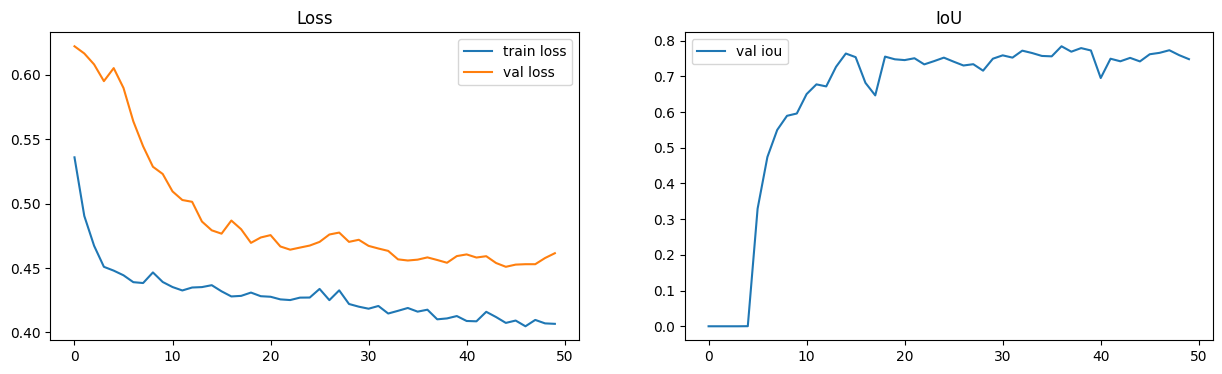

In [52]:
set_seed()
model = SegNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = DiceLoss(mode='binary')
train(model, criterion, optimizer, train_dataloader, valid_dataloader)

Удалось достигнуть IoU = 0.7838454246520996. По сравнению с BCE лосс уменьшается более стабильно и плавно.

### 2. Обучение SegNet на Focal Loss.

In [53]:
def FocalLoss(logits, targets):
    return sigmoid_focal_loss(
        logits,
        targets,
        gamma=1,
        reduction='mean'
    )

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 0


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 0: train loss = 0.23434003815054893


  0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 48: val loss = 0.2055196911096573
Epoch 48: val iou = 0.0821148231625557
Epoch 49


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 49: train loss = 0.19724571704864502


  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 49: val loss = 0.20475398004055023
Epoch 49: val iou = 0.11905627697706223
Epoch with max val iou = 4


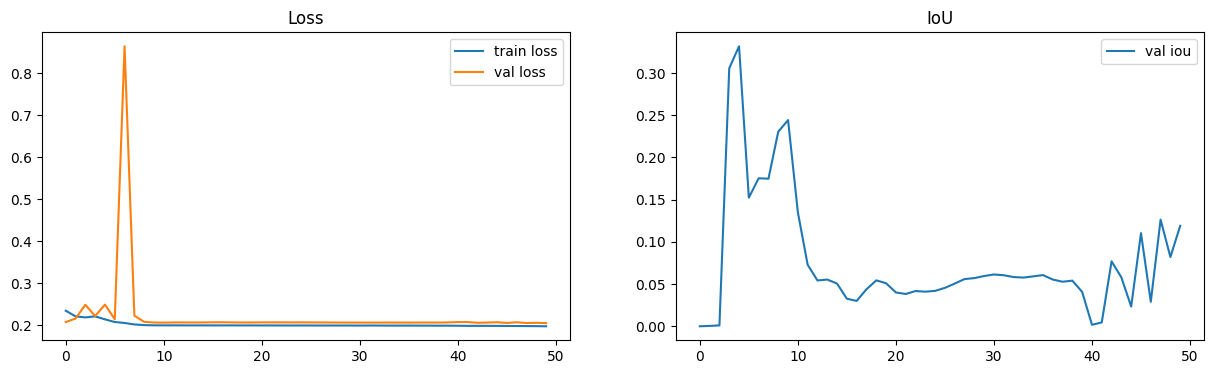

In [54]:
set_seed()
model = SegNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = FocalLoss
train(model, FocalLoss, optimizer, train_dataloader, valid_dataloader)

На Focal Loss наша модель переобучилась. Лучший score был достигнут ещё на 4 эпохе и был равен 0.33174940943717957.

### Вывод

Dice Loss сходился более стабильно. У BCE и Focal Loss он достиг своего минимума где-то на 10 итерации и далее заметно не менялся.  
Dice Loss показал лучшую метрику IoU = 0.7838454246520996. на 36 эпохе.  
Focal Loss показал самые низкий score = 0.33174940943717957. Скорее всего, это связано с тем, что в наших данных нет сильного дисбаланса классов: фоновых пикселей поровну с пикселями, где находятся меланомы и родинки.

# Задание: Новая модель!

## Модель U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

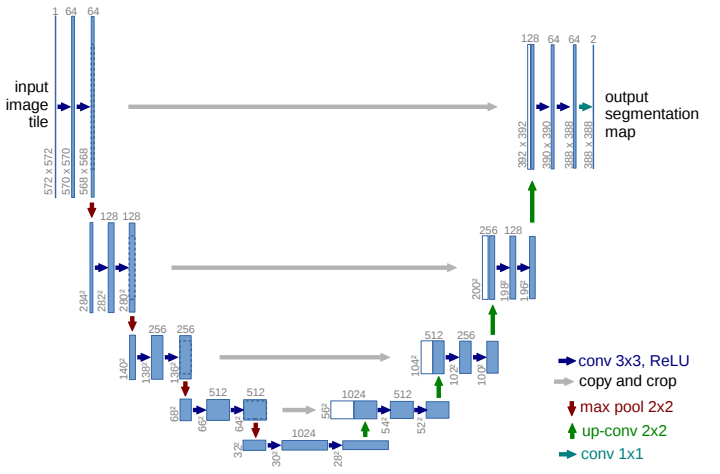

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

В оригинальной статье авторы не использовали padding внутри модели (это видно по тому, что размеры карты признаков уменьшаются на 2 каждый раз при движении от слоя к слою). При этом размеры входных изображений авторы единоразово увеличили при помощи mirror padding.

В этом домашнем задании вы можете применить альтернативный подход - сохранять размеры карт признаков при помощью padding = 1 во внутренних слоях.  

In [55]:
import torch.nn.functional as F
import torch.nn as nn

Для реализации UNet вы можете написать классы блоков энкодера и декодера отдельно, как мы сделали при реализации SegNet.

In [61]:
class EncoderBlockUNet(nn.Module):
    def __init__(self, in_channels, out_channels, padding = 1):
        super(EncoderBlockUNet, self).__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        skip = self.layers(x)
        x = self.maxpooling(skip)
        return x, skip

In [62]:
class DecoderBlockUNet(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, padding=1):
        super(DecoderBlockUNet, self).__init__()

        self.upsample = nn.ConvTranspose2d(in_channels=in_channels, out_channels=out_channels, kernel_size=2, stride=2)

        self.layers = nn.Sequential(
            nn.Conv2d(in_channels=out_channels + skip_channels, out_channels=out_channels, kernel_size=3, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, skip):
        x = self.upsample(x)
        x = torch.cat([x, skip], dim=1)
        x = self.layers(x)

        return x

In [63]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels = 1, num_features = 64) -> None:
        super(UNet, self).__init__()

        # Encoder
        self.encoder0 = EncoderBlockUNet(in_channels, num_features) # 3 -> 64
        self.encoder1 = EncoderBlockUNet(num_features, num_features * 2) # 64 -> 128
        self.encoder2 = EncoderBlockUNet(num_features * 2, num_features * 4) # 128 -> 256
        self.encoder3 = EncoderBlockUNet(num_features * 4, num_features * 8) # 256 -> 512
        self.encoder4 = EncoderBlockUNet(num_features * 8, num_features * 16) # 512 -> 1024

        # Decoder
        self.decoder4 = DecoderBlockUNet(num_features * 16, num_features * 16, num_features * 8)
        self.decoder3 = DecoderBlockUNet(num_features * 8, num_features * 8, num_features * 4)
        self.decoder2 = DecoderBlockUNet(num_features * 4, num_features * 4, num_features * 2)
        self.decoder1 = DecoderBlockUNet(num_features * 2, num_features * 2, num_features)
        self.decoder0 = DecoderBlockUNet(num_features, num_features, num_features)

        self.conv = nn.Conv2d(num_features, out_channels, kernel_size=1)

    def forward(self, x):
        # encoder
        x, skip0 = self.encoder0(x)
        x, skip1 = self.encoder1(x)
        x, skip2 = self.encoder2(x)
        x, skip3 = self.encoder3(x)
        x, skip4 = self.encoder4(x)

        # decoder
        x = self.decoder4(x, skip4)
        x = self.decoder3(x, skip3)
        x = self.decoder2(x, skip2)
        x = self.decoder1(x, skip1)
        x = self.decoder0(x, skip0)

        output = self.conv(x)

        return output

In [64]:
unet_model = UNet().to(device)

## Обучите UNet

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.



### 1. BCE.

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 0


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 0: train loss = 0.5072644352912903


  0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 48: val loss = 0.3396543264389038
Epoch 48: val iou = 0.680840790271759
Epoch 49


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 49: train loss = 0.11599957942962646


  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 49: val loss = 0.1891344040632248
Epoch 49: val iou = 0.779856264591217
Epoch with max val iou = 38


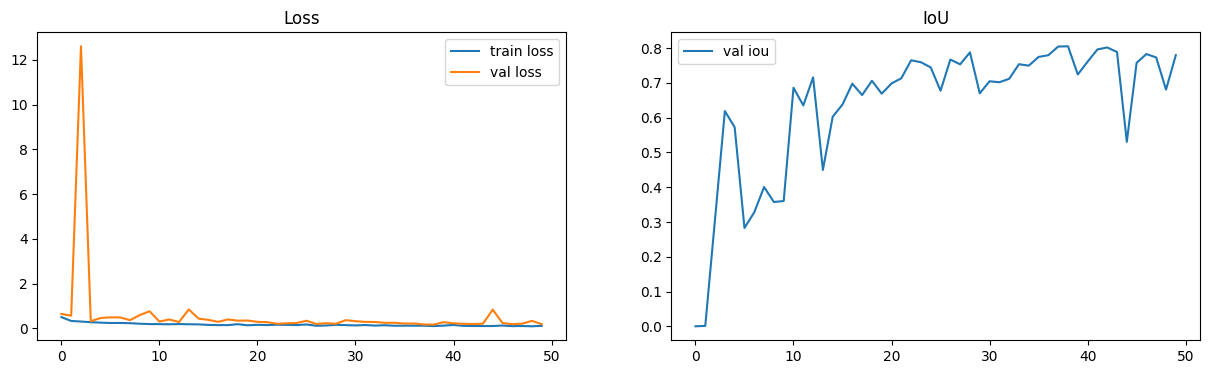

In [65]:
set_seed()
optimizer = torch.optim.Adam(unet_model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()
train(unet_model, criterion, optimizer, train_dataloader, valid_dataloader)

### 2. Dice.

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 0


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 0: train loss = 0.4362790286540985


  0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 48: val loss = 0.12612849473953247
Epoch 48: val iou = 0.785122275352478
Epoch 49


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 49: train loss = 0.055848628282547


  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 49: val loss = 0.12113896012306213
Epoch 49: val iou = 0.7932981848716736
Epoch with max val iou = 44


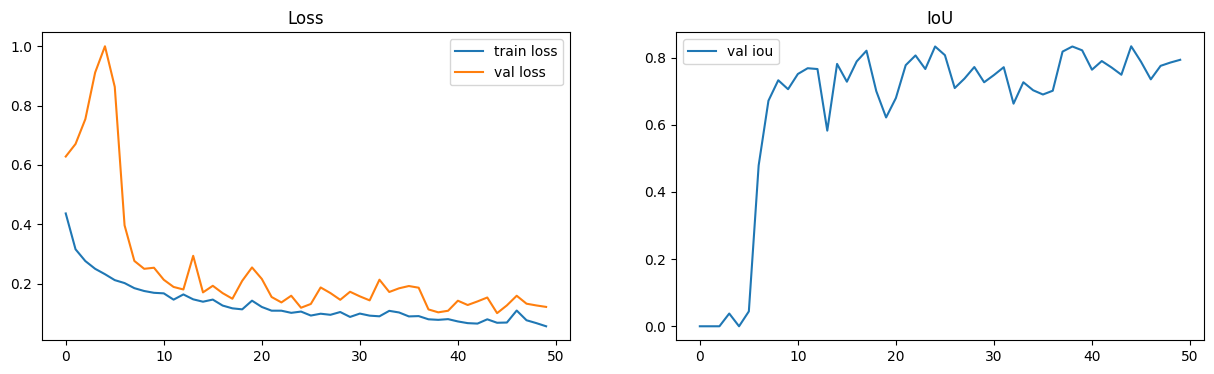

In [66]:
set_seed()
unet_model = UNet().to(device)
optimizer = torch.optim.Adam(unet_model.parameters(), lr=1e-3)
criterion = DiceLoss(mode='binary')
train(unet_model, criterion, optimizer, train_dataloader, valid_dataloader)

### 3. Focal.

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 0


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 0: train loss = 0.16599939204752445


  0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 48: val loss = 0.03115066234022379
Epoch 48: val iou = 0.8090970516204834
Epoch 49


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 49: train loss = 0.023068417329341173


  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 49: val loss = 0.034702674485743046
Epoch 49: val iou = 0.7987127900123596
Epoch with max val iou = 42


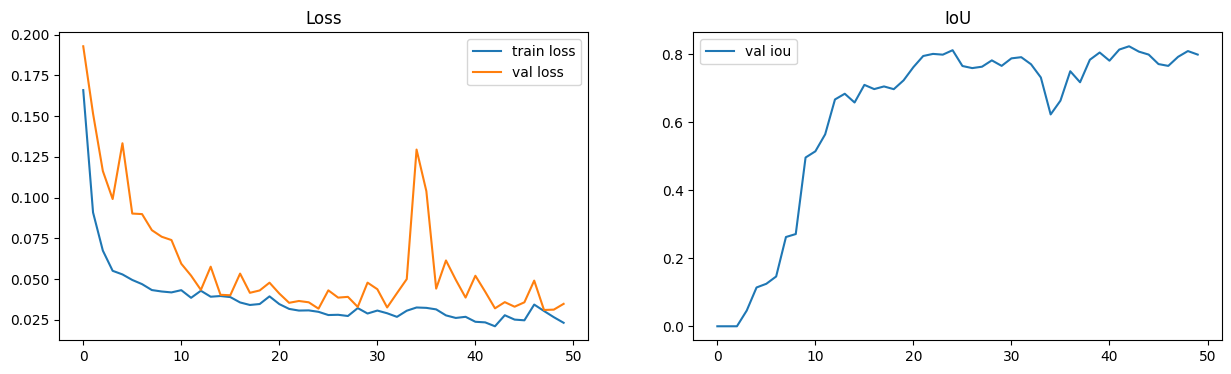

In [67]:
set_seed()
unet_model = UNet().to(device)
optimizer = torch.optim.Adam(unet_model.parameters(), lr=1e-3)
criterion = FocalLoss
train(unet_model, criterion, optimizer, train_dataloader, valid_dataloader)

### Вывод

1. UNet выдала самую высокую IoU = 0.8335539698600769.
2. UNet по всем лоссам в качестве превзошла SegNet.
3. SegNet обучалась быстрее UNet:
- BCE 3 min против 5 min
- Dice 4 min против 5 min
- Focal 3 min против 5 min
4. По графикам IoU видно, что у UNet хорошее качество достигается значительно раньше, чем у SegNet (требуется меньше эпох). На Focal Loss UNet превзошла SegNet в качестве >2 раза. Обучение происходило чуть дольше, но "реальное" время обучения (до эпохи с лучшим качеством) значительно меньше. Таким образом, UNet показала себя лучше SegNet-a.